# **Jigsaw Toxic Comment Classification Dataset — Exploratory Data Analysis**

Ноутбук містить EDA для датасету токсичних коментарів, який буде використано для навчання моделі яка буде ідентифікуівти та класифікувати токсичні коментарі по категоріям токсичності.

**Мета аналізу:**

• ознайомитися зі структурою датасету  
• перевірити наявність пропущених значень та дублікатів  
• проаналізувати розподіл класів  
• дослідити дисбаланс між токсичними категоріями  
• проаналізувати співвідношення токсичних та нетоксичних коментарів  
• дослідити розподіл довжини текстів  
• отримати загальне розуміння особливостей даних перед навчанням моделі

**У цьому проєкті використовується задача (multi-label) класифікації**, де один коментар може одночасно належати до кількох категорій токсичності:

• toxic  
• severe_toxic  
• obscene  
• threat  
• insult  
• identity_hate  

Датасет використовується для побудови моделі на основі попередньо навченої архітектури BERT із подальшим Fine-Tuning для задачі класифікації токсичних коментарів.

**Джерело датасету:**

Jigsaw Toxic Comment Classification Challenge (Kaggle)

https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/toxic-comment-classification/notebook')
os.getcwd()

'/content/drive/MyDrive/toxic-comment-classification/notebook'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# зчитуємо файл
df = pd.read_csv("../data/train.csv")
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [ ]:
# розмір датасету
df.shape

(159571, 8)

In [ ]:
df.dtypes

,0
id,object
comment_text,object
toxic,int64
severe_toxic,int64
obscene,int64
threat,int64
insult,int64
identity_hate,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [ ]:
# перевірка на дублікати
df.duplicated().sum()

np.int64(0)

In [ ]:
# Перевірка пропущених значень
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [ ]:
# Описова статистика
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# приклади коментарів
for i in range(5):
    print(df['comment_text'][i])
    print("="*80)

Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.
"
More
I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want 

In [ ]:
# Перевірка класів на дисбаланс
labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

df[labels].sum()

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


In [ ]:
# Перевірка розподілу коментарів на токсичні/нетоксичні
df['no_label']=(df[labels].sum(axis=1)==0)

df['no_label'].value_counts()

,count
no_label,
True,143346
False,16225


In [ ]:
# Рахуємо яка кількість комментарів можуть мати декілька міток токсичності (від 1 до 6)
df['label_count']=df[labels].sum(axis=1)
df['label_count'].value_counts()

,count
label_count,
0,143346
1,6360
3,4209
2,3480
4,1760
5,385
6,31


In [ ]:
# Довжина коментарів
df['comment_length']=df['comment_text'].apply(len)
df.head(20)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,no_label,label_count,comment_length
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,True,0,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,True,0,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,True,0,233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,True,0,622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,True,0,67
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0,True,0,65
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0,False,4,44
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0,True,0,115
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0,True,0,472
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0,True,0,70


In [ ]:
# описова статистика довжини коментарів по всьому датасету
df['comment_length'].describe()

,comment_length
count,159571.000000
mean,394.073221
std,590.720282
min,6.000000
25%,96.000000
50%,205.000000
75%,435.000000
max,5000.000000


In [ ]:
# Середня довжина коментарів по групам токсичні/нетоксичні
toxic_comments=df[df['toxic']==1]
non_toxic=df[df['toxic']==0]

print(toxic_comments['comment_length'].mean())
print(non_toxic['comment_length'].mean())

295.24604420034
404.5493391185012


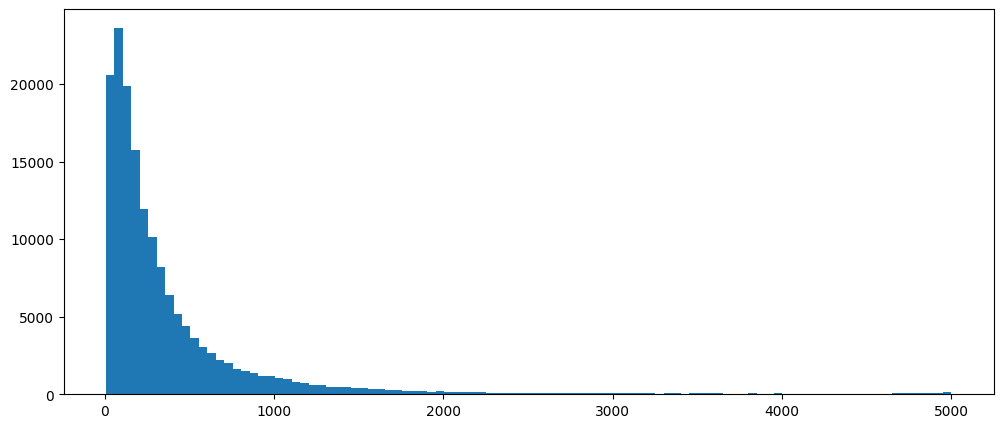

In [ ]:
# Гістограма розподілу довжини коментарів
plt.figure(figsize=(12,5))

plt.hist(df['comment_length'],bins=100)
plt.show()

In [ ]:
# Аналіз розподілу довжини коментарів за допомогою 95-го и 99-го персентилей
print(df['comment_length'].quantile(0.95))
print(df['comment_length'].quantile(0.99))


1355.0
3444.0


## **ВИСНОВКИ**
У ході проведення EDA датасету виявлено що
у датасеті відсутні пропущені значення, відсутні дублікати.
Текст виглядає природним і не містить явного сміття ( unicode символів , html і ін.)Тому рекомендовано зробити мінімальну обробку даних оскільки BERT вже враховує контекст слів та розуміє значення слова залежно від контексту.
А саме зробити очистку тексту від непотрібних символів , видалити зайві пробіли на початку та в кінці.

Виявлено серйозний дисбаланс класів, наприклад класи
toxic : threat ( 15294 : 478 ) , toxic : identity_hate ( 15294 : 1405 ) що означає що рідкісні класи можуть погано розпізнаватись моделлю. Для об'єктивності оцінки якості моделі рекомендовано використовувати метрики F1-score,Precision,Recall і рекомендовано зробити балансування класів (class weights).

Більшість коментарів не є токсичними.
- Не токсичні складають 143346
- Токсичні: 16225

Виходячи із аналізу кількості міток, виявлених у категорій токсичності ( 1 → 6360 , 2 → 3480 , 3 → 4209 , 4 → 1760, 5 → 385 , 6 → 31 ) можна сказати що деякі коментарі можуть мати кілька токсичних характеристик одночасно, що говорить про Multi-label классификацію.

Аналіз довжини коментарів показує , що більшість коментарів відносно короткі, але є невелика кількість дуже довгих повідомлень ( описові показники це підтерджують).

Середня загальна довжина коментарів по всьому датасету становить приблизно 394 символи (mean = 394). При цьому медіана (205 символів) значно нижча за середнє значення, що вказує на наявність невеликої кількості дуже довгих коментарів.

Розподіл довжини коментарів за 95-м і 99-м персентилем показав що:
- 95% коментарів коротше 1355 символів
- 99% майже усіх коментарів < 3444 символів

Отже ~ 95% даних — короткі комментарі до 1355 символів
- 4-5% даних — довгі коментарі ( до 3444 символів )
- ~1% даних - дуже довгі ( до 5000 символів )